In [10]:
import os 

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [11]:
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
from langchain.chat_models import init_chat_model
model = init_chat_model("groq:openai/gpt-oss-20b")

In [12]:
from langchain_tavily import TavilySearch

tavilytool = TavilySearch(
      max_results= 5,
      topic = "general"

)
tavilytool.invoke("What is current AI news")

{'query': 'What is current AI news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business ...',
   'content': 'August 26, 2026\n\n### HoneyBook bets on agentic AI to streamline small business operations with its new Claude connector\n\nWorld of Work\n\nAugust 6, 2026\n\n### Zuckerberg details Meta’s personal AI superintelligence strategy\n\nAI and Us\n\nJuly 30, 2026\n\n#### Deep Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### China’s AI just mapped its entire renewable energy grid. Here’s why the rest of the world should pay attention [...] Entertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly

In [13]:
from langchain.tools import tool
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [14]:
from langchain.agents import create_agent

agent = create_agent(model,[calc,tavilytool])

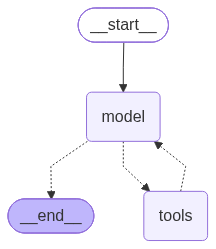

In [15]:
agent

In [ ]:
user_input = "What is the current AI news for Anthropic and calculate 5+5"

for step in agent.stream(
    {"messages":user_input},
    stream_mode = "values"  #to display only the values 
):
    step["messages"][-1].pretty_print() 



================================ Human Message =================================

What is the current AI news for Anthropic and calculate 5+5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0f6cb5ed-7df9-4392-8eba-14a217b4a54c)
 Call ID: fc_0f6cb5ed-7df9-4392-8eba-14a217b4a54c
  Args:
    query: Anthropic AI news 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Anthropic AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://x.com/i/trending/2093046322362245555", "title": "Anthropic Launches Model Hardware Standard for AI- ...", "content": "Log inSign up\n\n## Trending\n\n# Anthropic Launches Model Hardware Standard for AI-Controlled Lab Equipment\n\nLast updated Aug 29, 2026\n\nAnthropic unveiled its Model Hardware Standard (MHS) on August 27, 